# FreshTrack Automated Fruit Sorting, Quality Control, and Counting Pipeline
This notebook implements an end-to-end automated computer vision pipeline using OpenCV, NumPy, and Matplotlib. The pipeline is designed for warehouse environments to identify fruit types by color, clean up camera images, extract shape boundaries, and perform batch counting of individual round fruits.


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Environment Setup & Path Mapping
DATASET_ROOT = 'D:/Fusemachines_Fellowship/Week10/dataset/fruits-360_100x100/fruits-360/'

def load_first_image_from_dir(folder_path):
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Target directory does not exist: {folder_path}")
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not files:
        raise FileNotFoundError(f"No image files found in folder: {folder_path}")
    return os.path.join(folder_path, files[0])

# Dynamic scanner to find files in current, parent, or dataset directories
def find_image(filename):
    search_paths = [
        filename, 
        os.path.join('..', filename), 
        os.path.join('dataset', filename),
        os.path.join(DATASET_ROOT, filename)
    ]
    for path in search_paths:
        if os.path.exists(path):
            return path
    # Check with alternative extensions (.jpeg vs .jpg)
    base, ext = os.path.splitext(filename)
    alt_ext = '.jpeg' if ext.lower() == '.jpg' else '.jpg'
    alt_filename = base + alt_ext
    for path in [
        alt_filename, 
        os.path.join('..', alt_filename), 
        os.path.join('dataset', alt_filename),
        os.path.join(DATASET_ROOT, alt_filename)
    ]:
        if os.path.exists(path):
            return path
    return None

# Check dataset root path and map files
if os.path.exists(DATASET_ROOT):
    print(f"Fruits-360 dataset root verified: {DATASET_ROOT}")
    IMAGE_MAP = {
        'red_apple.jpg': load_first_image_from_dir(os.path.join(DATASET_ROOT, 'Test/Apple Red 1')),
        'green_apple.jpg': load_first_image_from_dir(os.path.join(DATASET_ROOT, 'Test/Apple Granny Smith 1')),
        'banana.jpg': load_first_image_from_dir(os.path.join(DATASET_ROOT, 'Test/Banana 1')),
        'lime.jpg': load_first_image_from_dir(os.path.join(DATASET_ROOT, 'Test/Limes 1')),
        'orange.jpg': load_first_image_from_dir(os.path.join(DATASET_ROOT, 'Test/Orange 1')),
        'strawberry.jpg': load_first_image_from_dir(os.path.join(DATASET_ROOT, 'Test/Strawberry 1'))
    }
else:
    print(f"Warning: Dataset root not found at '{DATASET_ROOT}'. Creating simulated image dictionary.")
    IMAGE_MAP = {
        'red_apple.jpg': 'red_apple_sim.jpg',
        'green_apple.jpg': 'green_apple_sim.jpg',
        'banana.jpg': 'banana_sim.jpg',
        'lime.jpg': 'lime_sim.jpg',
        'orange.jpg': 'orange_sim.jpg',
        'strawberry.jpg': 'strawberry_sim.jpg'
    }
    for k, v in IMAGE_MAP.items():
        canvas = np.zeros((100, 100, 3), dtype=np.uint8)
        if 'red' in k: color = (0, 0, 255)
        elif 'green' in k: color = (0, 255, 0)
        elif 'banana' in k: color = (0, 255, 255)
        elif 'lime' in k: color = (0, 200, 0)
        elif 'orange' in k: color = (0, 165, 255)
        else: color = (0, 0, 200) # Strawberry
        cv2.circle(canvas, (50, 50), 40, color, -1)
        cv2.imwrite(v, canvas)

# Standalone image paths
CHESSBOARD_PATH = 'chessboard.png'
MIXED_BOWL_PATH = 'mixed_fruit_bowl.jpeg'
MORPHOLOGY_PATH = 'morphology.png'

# Dynamic programmatic generators for calibration & verification templates
def get_or_create_chessboard(path):
    found = find_image(path)
    if found:
        return found
    chessboard = np.zeros((400, 400), dtype=np.uint8)
    square_size = 50
    for i in range(8):
        for j in range(8):
            if (i + j) % 2 == 1:
                chessboard[i*square_size:(i+1)*square_size, j*square_size:(j+1)*square_size] = 255
    cv2.imwrite(path, cv2.cvtColor(chessboard, cv2.COLOR_GRAY2BGR))
    return path

def get_or_create_mixed_bowl(path):
    found = find_image(path)
    if found:
        return found
    # Create simulated bowl container of size 900x900 to ensure crop is in-bounds
    canvas = np.ones((900, 900, 3), dtype=np.uint8) * 255
    cv2.circle(canvas, (450, 450), 400, (200, 200, 200), -1)
    cv2.circle(canvas, (450, 450), 400, (100, 100, 100), 8)
    # Place circular nodes representing fruits (including one exactly in the crop region)
    cv2.circle(canvas, (300, 300), 100, (0, 0, 220), -1) # Red Apple
    cv2.circle(canvas, (550, 300), 95, (0, 220, 0), -1) # Green Apple
    cv2.circle(canvas, (629, 766), 80, (0, 140, 255), -1) # Target Orange sector (fits crop 646:886, 509:749)
    cv2.circle(canvas, (350, 600), 110, (0, 128, 255), -1) # Another Orange
    cv2.circle(canvas, (450, 450), 70, (0, 240, 240), -1) # Banana simulation
    cv2.imwrite(path, canvas)
    return path

def get_or_create_morphology_demo(path):
    found = find_image(path)
    if found:
        return found
    canvas = np.zeros((300, 300), dtype=np.uint8)
    # Text stroke
    cv2.putText(canvas, "FreshTrack", (30, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.2, 255, 6, cv2.LINE_AA)
    # Solid shapes
    cv2.circle(canvas, (80, 200), 40, 255, -1)
    cv2.rectangle(canvas, (160, 160), (240, 240), 255, -1)
    # Salt-and-pepper noise dots
    np.random.seed(42)
    for _ in range(100):
        x, y = np.random.randint(0, 300, 2)
        cv2.circle(canvas, (x, y), 2, 255, -1)
    # Internal shadow holes
    cv2.circle(canvas, (80, 200), 5, 0, -1)
    cv2.rectangle(canvas, (190, 190), (210, 210), 0, -1)
    cv2.imwrite(path, cv2.cvtColor(canvas, cv2.COLOR_GRAY2BGR))
    return path

IMAGE_MAP['chessboard.png'] = get_or_create_chessboard(CHESSBOARD_PATH)
IMAGE_MAP['mixed_bowl.jpg'] = get_or_create_mixed_bowl(MIXED_BOWL_PATH)
IMAGE_MAP['morphology.png'] = get_or_create_morphology_demo(MORPHOLOGY_PATH)

print("Path Verification and Fallback canvas setup completed.")


Fruits-360 dataset root verified: D:/Fusemachines_Fellowship/Week10/dataset/fruits-360_100x100/fruits-360/
Path Verification and Fallback canvas setup completed.


## PART A — COLOR SPACE & FRUIT SEGMENTATION

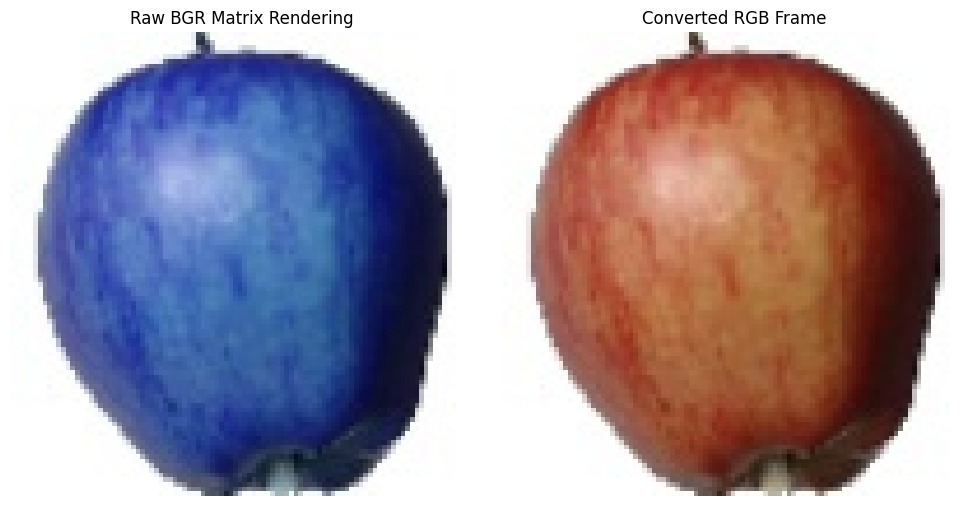

In [2]:
# A.1: BGR vs RGB Discrepancy
img_bgr = cv2.imread(IMAGE_MAP['red_apple.jpg'])
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Plotting side-by-side comparison to demonstrate channel inversion
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_bgr)
axes[0].set_title('Raw BGR Matrix Rendering')
axes[0].axis('off')

axes[1].imshow(img_rgb)
axes[1].set_title('Converted RGB Frame')
axes[1].axis('off')

plt.tight_layout()
plt.show()


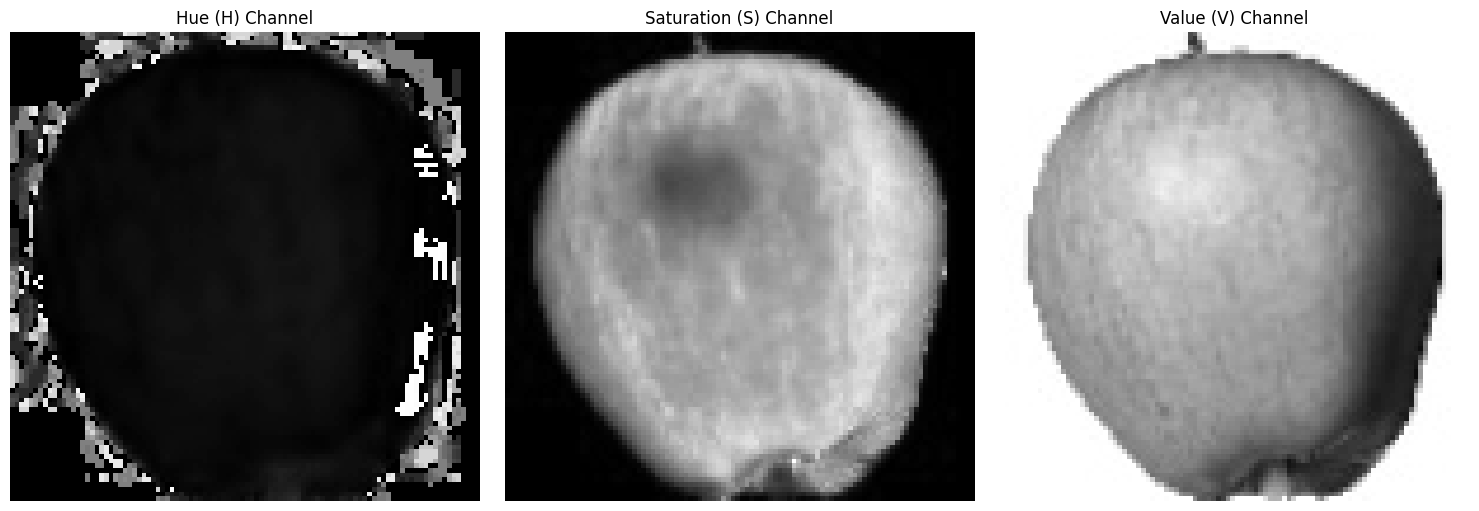

In [3]:
# A.2: HSV Channel Component Space
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h_channel, s_channel, v_channel = cv2.split(img_hsv)

# Plotting individual channel components
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(h_channel, cmap='gray')
axes[0].set_title('Hue (H) Channel')
axes[0].axis('off')

axes[1].imshow(s_channel, cmap='gray')
axes[1].set_title('Saturation (S) Channel')
axes[1].axis('off')

axes[2].imshow(v_channel, cmap='gray')
axes[2].set_title('Value (V) Channel')
axes[2].axis('off')

plt.tight_layout()
plt.show()


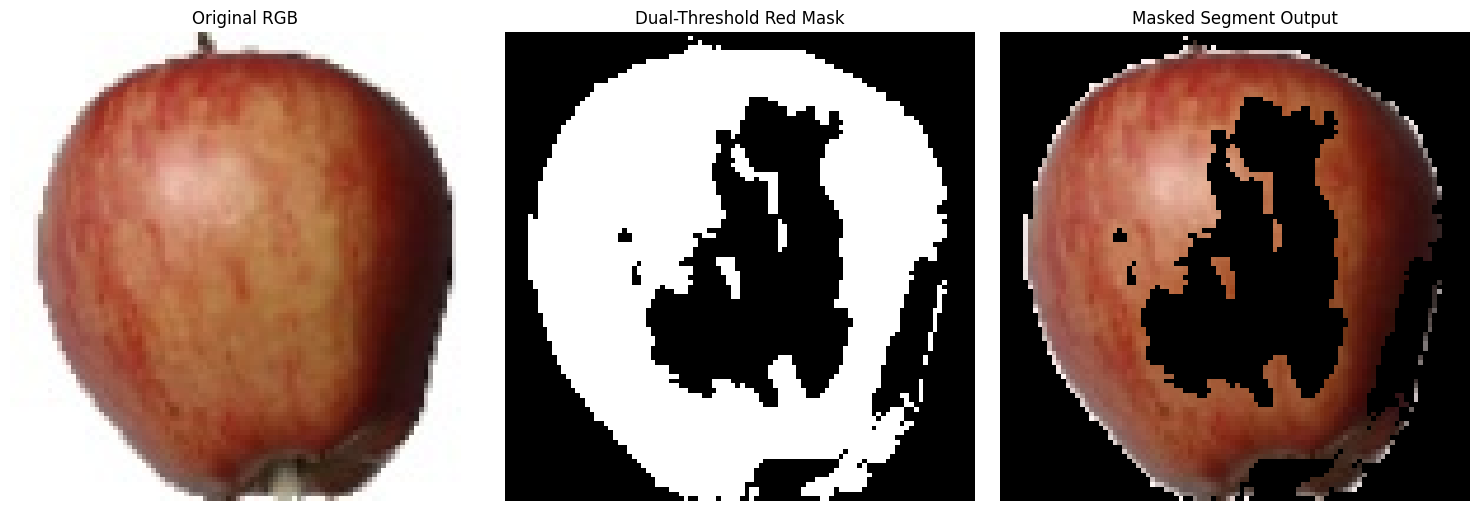

In [4]:
# A.3: Dual-Threshold Red Mask Wrapping
# Red wraps around the HSV Hue boundary; we construct two operational limits
lower_red1 = np.array([0, 10, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 10, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)
red_mask = cv2.bitwise_or(mask1, mask2)
segmented_result = cv2.bitwise_and(img_rgb, img_rgb, mask=red_mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original RGB')
axes[0].axis('off')

axes[1].imshow(red_mask, cmap='gray')
axes[1].set_title('Dual-Threshold Red Mask')
axes[1].axis('off')

axes[2].imshow(segmented_result)
axes[2].set_title('Masked Segment Output')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### A.4: Calibration Boundary Table

The stable HSV operational windows determined for sorting the target collection are tracked below:

| Fruit | H_min | H_max | S_min | S_max | V_min | V_max |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Red Apple | 0 / 170 | 10 / 180 | 10 | 255 | 50 | 255 |
| Green Apple | 35 | 85 | 40 | 255 | 40 | 255 |
| Banana | 15 | 30 | 40 | 255 | 40 | 255 |
| Lime | 30 | 50 | 40 | 255 | 40 | 255 |
| Orange | 10 | 25 | 60 | 255 | 60 | 255 |
| Strawberry | 0 / 165 | 15 / 180 | 50 | 255 | 50 | 255 |


Maximum Pixel Difference between NumPy & OpenCV Normalization: 1


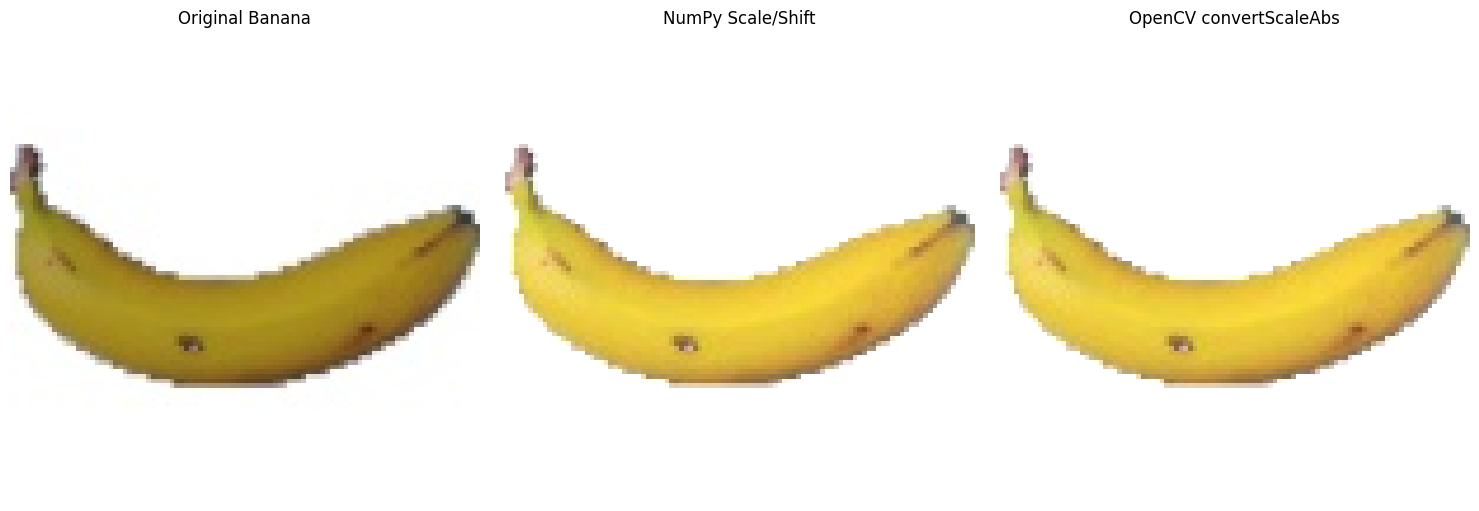

In [5]:
# A.5: Custom Contrast/Brightness Normalization
alpha = 1.3
beta = 20
dark_banana_bgr = cv2.imread(IMAGE_MAP['banana.jpg'])
dark_banana_rgb = cv2.cvtColor(dark_banana_bgr, cv2.COLOR_BGR2RGB)

# NumPy-vectorized contrast scaling and brightness shifting with clipping limits
normalized_numpy = np.clip(dark_banana_rgb.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)
normalized_opencv = cv2.convertScaleAbs(dark_banana_rgb, alpha=alpha, beta=beta)

# Verification of identical matching
pixel_difference = np.max(np.abs(normalized_numpy.astype(np.int16) - normalized_opencv.astype(np.int16)))
print(f"Maximum Pixel Difference between NumPy & OpenCV Normalization: {pixel_difference}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(dark_banana_rgb)
axes[0].set_title('Original Banana')
axes[0].axis('off')

axes[1].imshow(normalized_numpy)
axes[1].set_title('NumPy Scale/Shift')
axes[1].axis('off')

axes[2].imshow(normalized_opencv)
axes[2].set_title('OpenCV convertScaleAbs')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### A.6: Theoretical Reflection on HSV vs RGB spaces

#### Why HSV is superior to RGB under illumination changes:
The RGB color space mixes luminance (brightness) and chrominance (color) information across all three channels. In warehouses where lighting is uneven, shadows or bright reflections scale the RGB values uniformly, distorting color boundary limits. Conversely, the HSV (Hue, Saturation, Value) space isolates lighting intensity in the **Value (V)** channel. The **Hue (H)** channel represents the dominant wavelength, which remains mostly unchanged under shadows or brightness variations. Thresholding on the H and S channels allows the pipeline to maintain robust color classifications independent of warehouse illumination variance.

#### Limitations in low-light environments:
When value levels drop near zero, the mathematical conversions from BGR to HSV become highly unstable. Low Value levels result in low signal-to-noise ratios, causing Saturation values to skew and Hue to fluctuate wildly. In dark environments (e.g., segmenting a very dark purple grape or blueberry), HSV fails because the color data collapses into noise.

## PART B — HISTOGRAMS & FILTERING

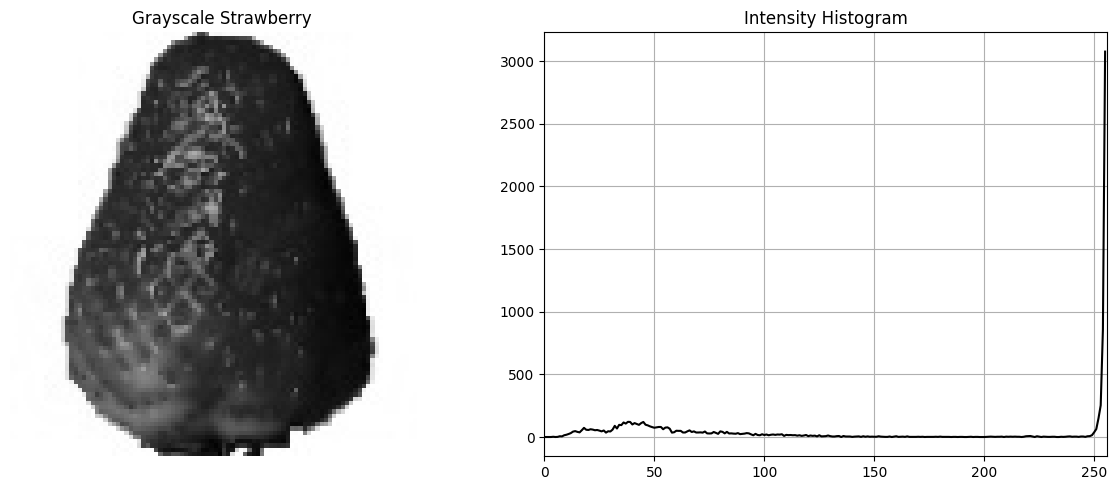

In [6]:
# B.1: Grayscale Exposure Signature
straw_bgr = cv2.imread(IMAGE_MAP['strawberry.jpg'])
straw_gray = cv2.cvtColor(straw_bgr, cv2.COLOR_BGR2GRAY)

hist = cv2.calcHist([straw_gray], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(straw_gray, cmap='gray')
axes[0].set_title('Grayscale Strawberry')
axes[0].axis('off')

axes[1].plot(hist, color='black', linewidth=1.5)
axes[1].set_xlim([0, 256])
axes[1].set_title('Intensity Histogram')
axes[1].grid(True)

plt.tight_layout()
plt.show()


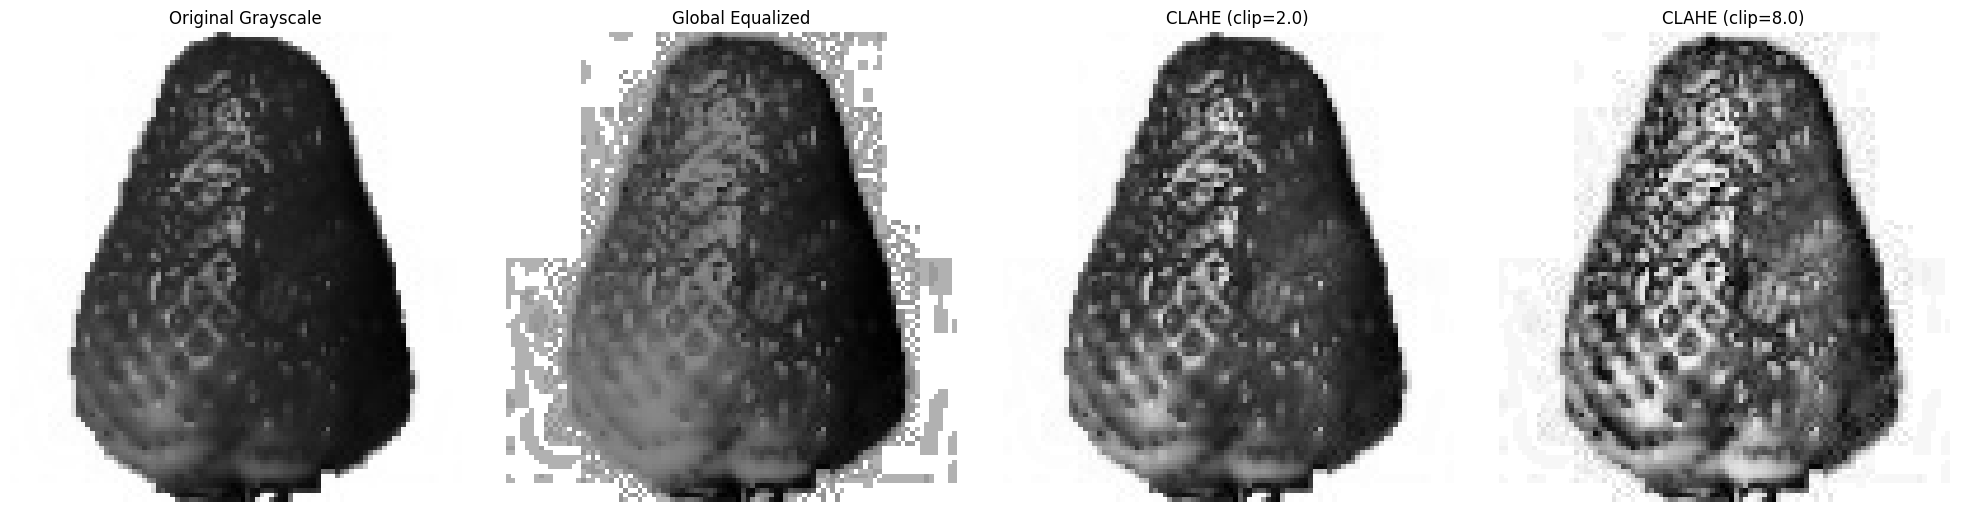

In [7]:
# B.2: Dynamic Range Equalization Matrix
global_eq = cv2.equalizeHist(straw_gray)

clahe_2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
straw_clahe_2 = clahe_2.apply(straw_gray)

clahe_8 = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8, 8))
straw_clahe_8 = clahe_8.apply(straw_gray)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(straw_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(global_eq, cmap='gray')
axes[1].set_title('Global Equalized')
axes[1].axis('off')

axes[2].imshow(straw_clahe_2, cmap='gray')
axes[2].set_title('CLAHE (clip=2.0)')
axes[2].axis('off')

axes[3].imshow(straw_clahe_8, cmap='gray')
axes[3].set_title('CLAHE (clip=8.0)')
axes[3].axis('off')

plt.tight_layout()
plt.show()


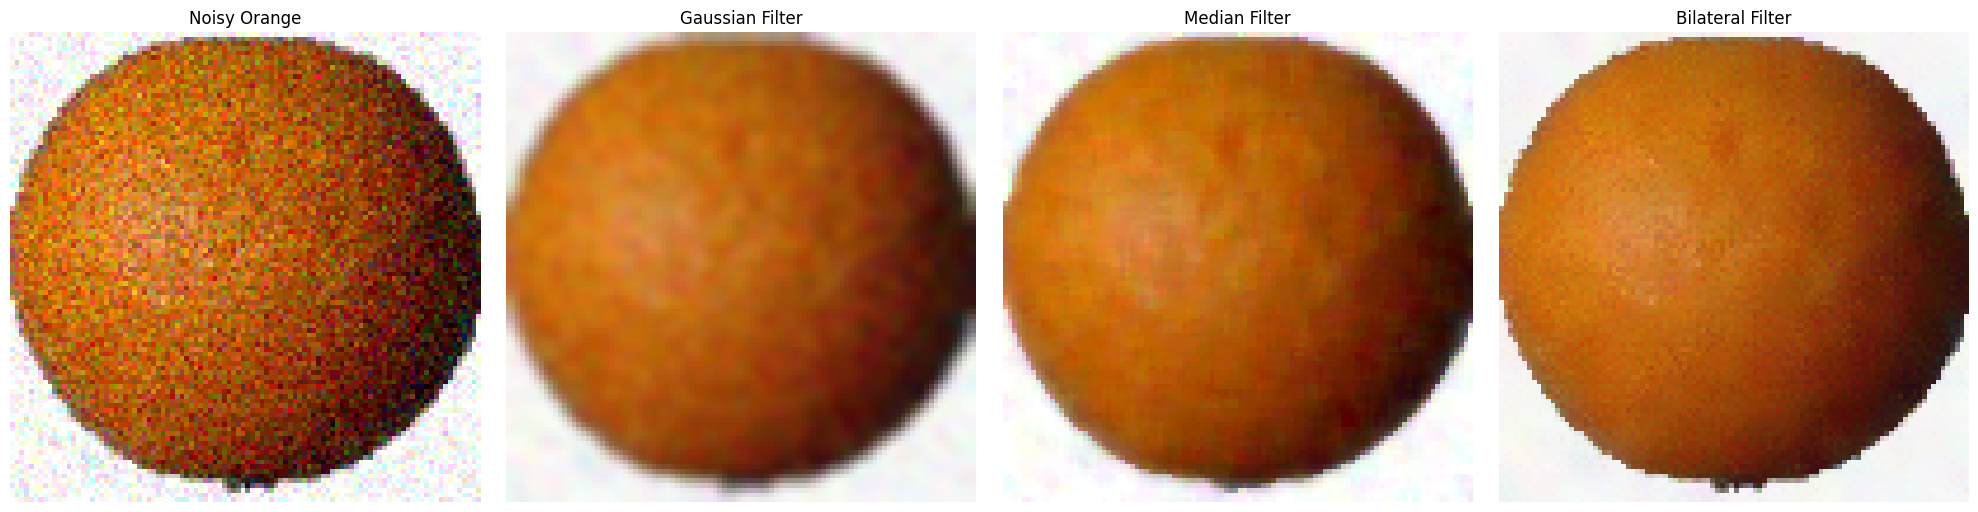

In [8]:
# B.3: Noise Mitigation Benchmarking
orange_bgr = cv2.imread(IMAGE_MAP['orange.jpg'])
orange_rgb = cv2.cvtColor(orange_bgr, cv2.COLOR_BGR2RGB)

# Inject synthetic Gaussian noise
np.random.seed(42)
noise = np.random.normal(0, 25, orange_rgb.shape).astype(np.int16)
noisy_orange = np.clip(orange_rgb.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Denoising filters
gauss_blur = cv2.GaussianBlur(noisy_orange, (5, 5), 1.5)
median_blur = cv2.medianBlur(noisy_orange, 5)
bilateral = cv2.bilateralFilter(noisy_orange, 9, 75, 75)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(noisy_orange)
axes[0].set_title('Noisy Orange')
axes[0].axis('off')

axes[1].imshow(gauss_blur)
axes[1].set_title('Gaussian Filter')
axes[1].axis('off')

axes[2].imshow(median_blur)
axes[2].set_title('Median Filter')
axes[2].axis('off')

axes[3].imshow(bilateral)
axes[3].set_title('Bilateral Filter')
axes[3].axis('off')

plt.tight_layout()
plt.show()


Mean Absolute Difference (MAD) between manual & OpenCV filter2D: 0.00000000


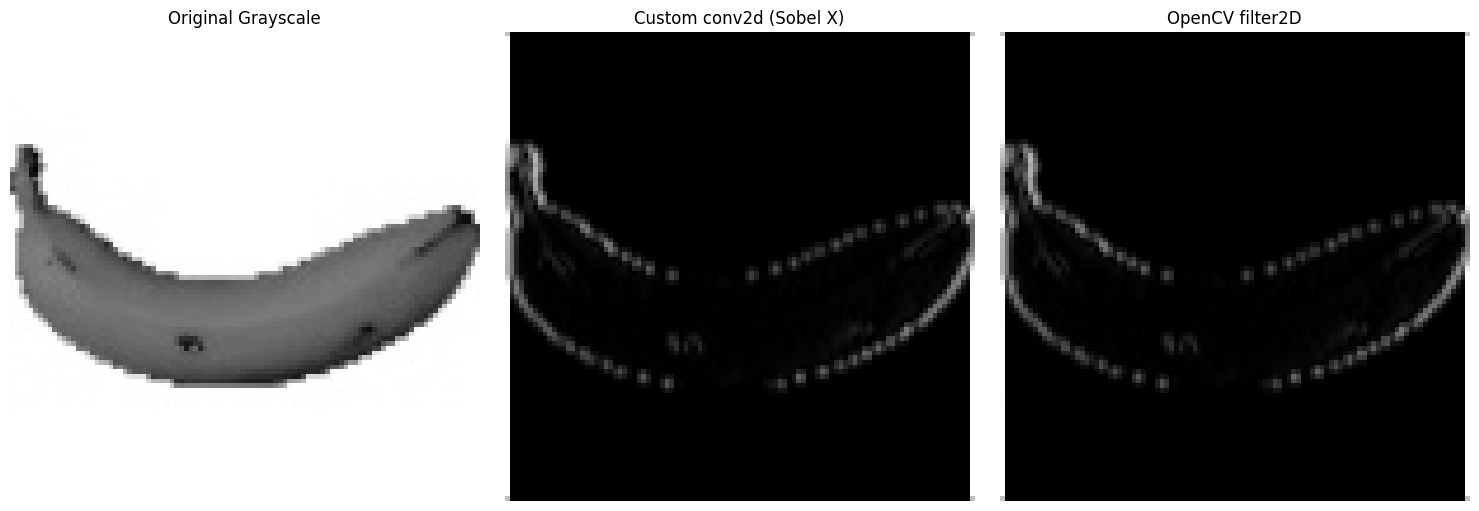

In [9]:
# B.4: Linear 2D Spatial Convolution Engine
banana_bgr = cv2.imread(IMAGE_MAP['banana.jpg'])
banana_gray = cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2GRAY)

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

def conv2d(image, kernel):
    h_img, w_img = image.shape
    h_k, w_k = kernel.shape
    pad_h = h_k // 2
    pad_w = w_k // 2
    
    # Zero-padded edge handling
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    # For true mathematical convolution, the kernel is flipped horizontally and vertically
    flipped_kernel = np.flip(np.flip(kernel, 0), 1)
    output = np.zeros_like(image, dtype=np.float32)
    
    for i in range(h_img):
        for j in range(w_img):
            region = padded[i:i+h_k, j:j+w_k]
            output[i, j] = np.sum(region * flipped_kernel)
            
    return output

manual_conv = conv2d(banana_gray, sobel_x)
# OpenCV's filter2D computes cross-correlation. To make it equivalent to true convolution,
# we flip the kernel before calling filter2D, and set borderType to BORDER_CONSTANT with value 0.
flipped_sobel = np.flip(np.flip(sobel_x, 0), 1)
opencv_conv = cv2.filter2D(banana_gray.astype(np.float32), -1, flipped_sobel, borderType=cv2.BORDER_CONSTANT)

mad = np.mean(np.abs(manual_conv - opencv_conv))
print(f"Mean Absolute Difference (MAD) between manual & OpenCV filter2D: {mad:.8f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(banana_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(np.abs(manual_conv), cmap='gray')
axes[1].set_title('Custom conv2d (Sobel X)')
axes[1].axis('off')

axes[2].imshow(np.abs(opencv_conv), cmap='gray')
axes[2].set_title('OpenCV filter2D')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## PART C — MORPHOLOGY & MASK CLEANUP

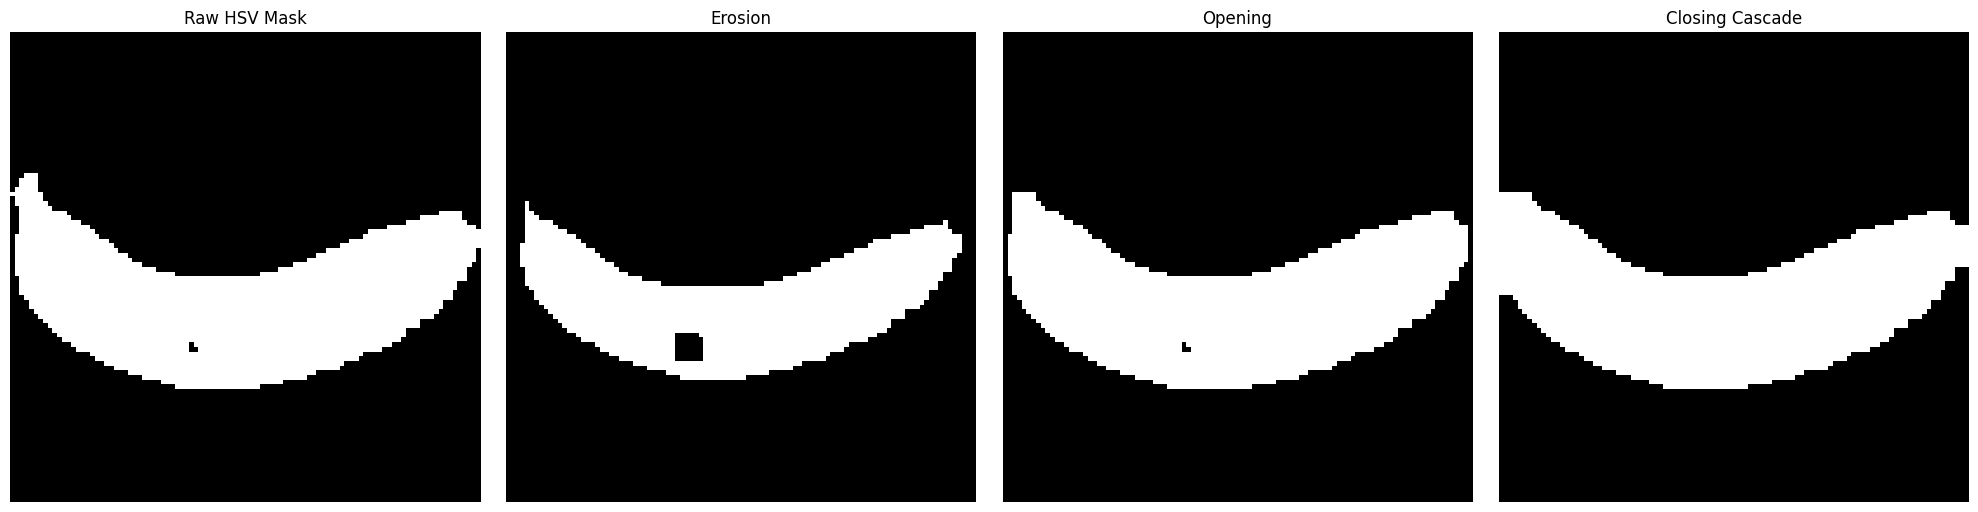

In [10]:
# C.1 & C.2: Binary Erosion and Opening/Closing Cascades
banana_bgr = cv2.imread(IMAGE_MAP['banana.jpg'])
banana_hsv = cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2HSV)
lower_yellow = np.array([15, 40, 40])
upper_yellow = np.array([30, 255, 255])
raw_mask = cv2.inRange(banana_hsv, lower_yellow, upper_yellow)

kernel_5x5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
eroded_mask = cv2.erode(raw_mask, kernel_5x5, iterations=1)
opened_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel_5x5)
closed_mask = cv2.morphologyEx(opened_mask, cv2.MORPH_CLOSE, kernel_5x5)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(raw_mask, cmap='gray')
axes[0].set_title('Raw HSV Mask')
axes[0].axis('off')

axes[1].imshow(eroded_mask, cmap='gray')
axes[1].set_title('Erosion')
axes[1].axis('off')

axes[2].imshow(opened_mask, cmap='gray')
axes[2].set_title('Opening')
axes[2].axis('off')

axes[3].imshow(closed_mask, cmap='gray')
axes[3].set_title('Closing Cascade')
axes[3].axis('off')

plt.tight_layout()
plt.show()


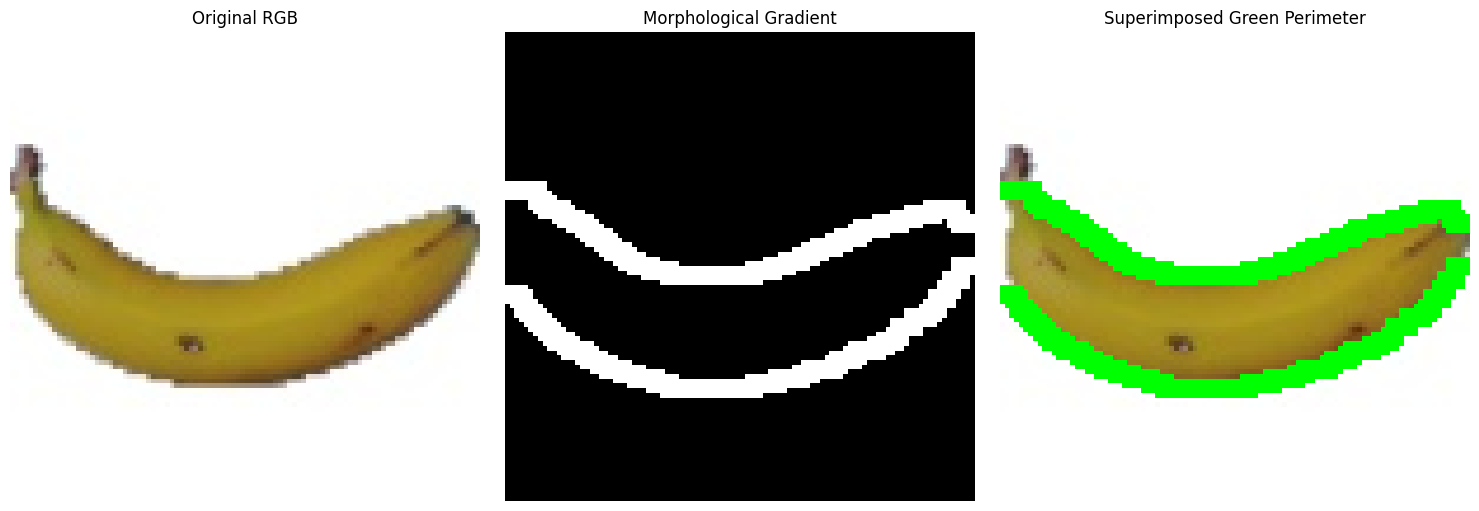

In [11]:
# C.3: Morphological Boundary Extraction
banana_rgb = cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2RGB)
gradient = cv2.morphologyEx(closed_mask, cv2.MORPH_GRADIENT, kernel_5x5)

# Superimpose perimeter boundary as a bright green overlay
overlay = banana_rgb.copy()
overlay[gradient > 0] = [0, 255, 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(banana_rgb)
axes[0].set_title('Original RGB')
axes[0].axis('off')

axes[1].imshow(gradient, cmap='gray')
axes[1].set_title('Morphological Gradient')
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title('Superimposed Green Perimeter')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### C.4: Multi-Channel Morphological Evaluation

#### Structural effects of direct BGR morphology:
Applying non-linear morphological operations (like erosion and dilation) channel-by-channel directly on BGR color images breaks the coordinated alignment of the boundaries between channels. Each channel has distinct intensity gradients. Shifting boundaries independently causes spatial misalignment at the borders, creating colored halos or fringes (edge color bleeding). To prevent spatial color artifacts, morphological filters must always be applied either to single-channel luminance planes (e.g., Value channel in HSV) or to binary masks.

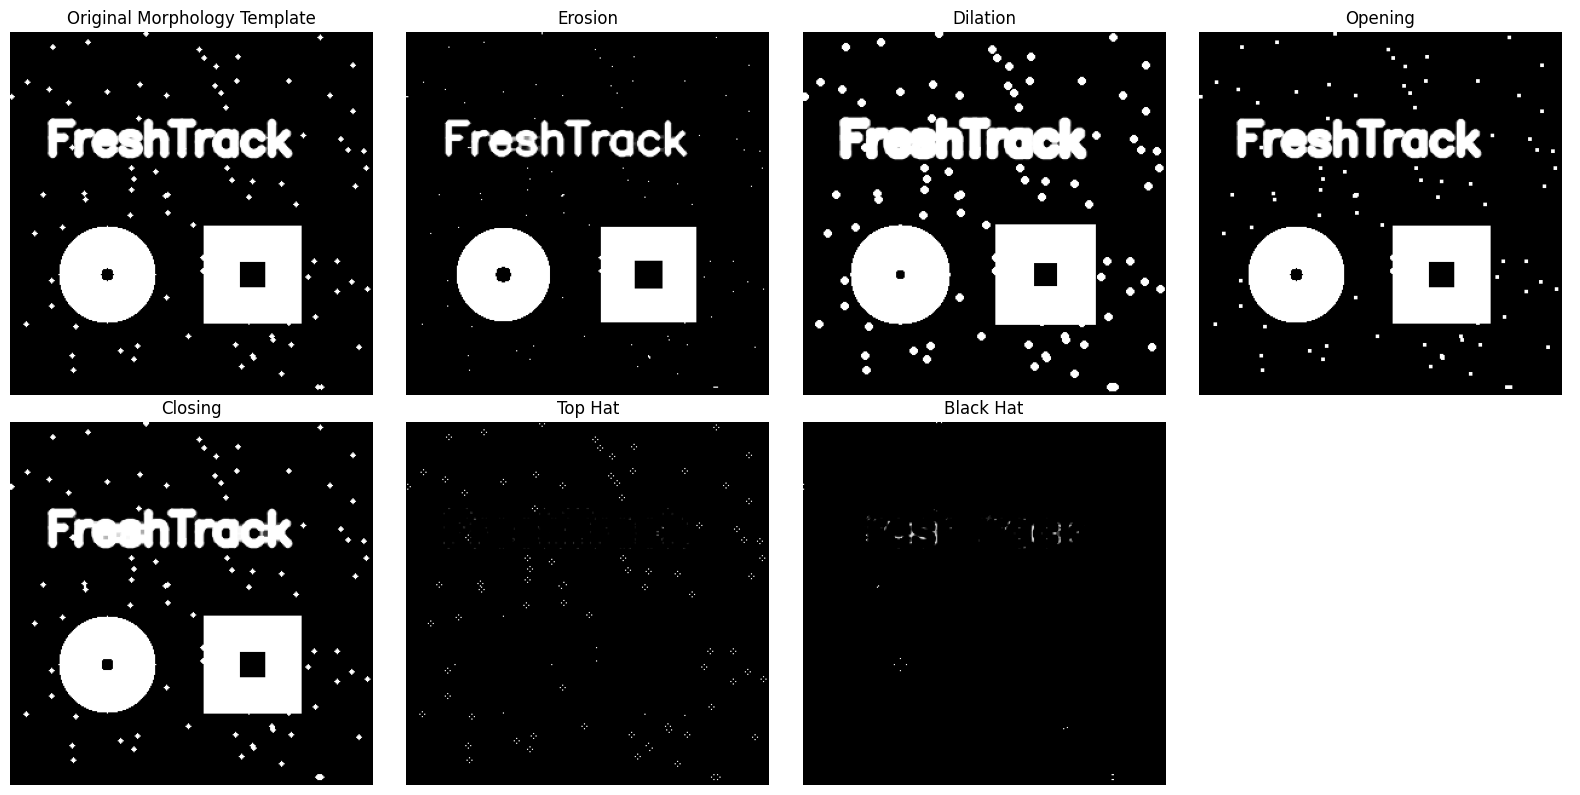

Morphology Stroke Isolation Analysis:
- Top Hat isolates fine bright stroke details by subtracting the opened background representation from the original image.
- Black Hat isolates fine dark elements (gaps/shadows) by subtracting the original image from its morphological closing.


In [12]:
# C.5: Template Target Validation
morph_bgr = cv2.imread(IMAGE_MAP['morphology.png'])
morph_gray = cv2.cvtColor(morph_bgr, cv2.COLOR_BGR2GRAY)
kernel_morph = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

erosion = cv2.erode(morph_gray, kernel_morph)
dilation = cv2.dilate(morph_gray, kernel_morph)
opening = cv2.morphologyEx(morph_gray, cv2.MORPH_OPEN, kernel_morph)
closing = cv2.morphologyEx(morph_gray, cv2.MORPH_CLOSE, kernel_morph)
tophat = cv2.morphologyEx(morph_gray, cv2.MORPH_TOPHAT, kernel_morph)
blackhat = cv2.morphologyEx(morph_gray, cv2.MORPH_BLACKHAT, kernel_morph)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(morph_gray, cmap='gray')
axes[0, 0].set_title('Original Morphology Template')
axes[0, 0].axis('off')

axes[0, 1].imshow(erosion, cmap='gray')
axes[0, 1].set_title('Erosion')
axes[0, 1].axis('off')

axes[0, 2].imshow(dilation, cmap='gray')
axes[0, 2].set_title('Dilation')
axes[0, 2].axis('off')

axes[0, 3].imshow(opening, cmap='gray')
axes[0, 3].set_title('Opening')
axes[0, 3].axis('off')

axes[1, 0].imshow(closing, cmap='gray')
axes[1, 0].set_title('Closing')
axes[1, 0].axis('off')

axes[1, 1].imshow(tophat, cmap='gray')
axes[1, 1].set_title('Top Hat')
axes[1, 1].axis('off')

axes[1, 2].imshow(blackhat, cmap='gray')
axes[1, 2].set_title('Black Hat')
axes[1, 2].axis('off')

axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

print("Morphology Stroke Isolation Analysis:")
print("- Top Hat isolates fine bright stroke details by subtracting the opened background representation from the original image.")
print("- Black Hat isolates fine dark elements (gaps/shadows) by subtracting the original image from its morphological closing.")


## PART D — SHAPE & FEATURE DETECTION

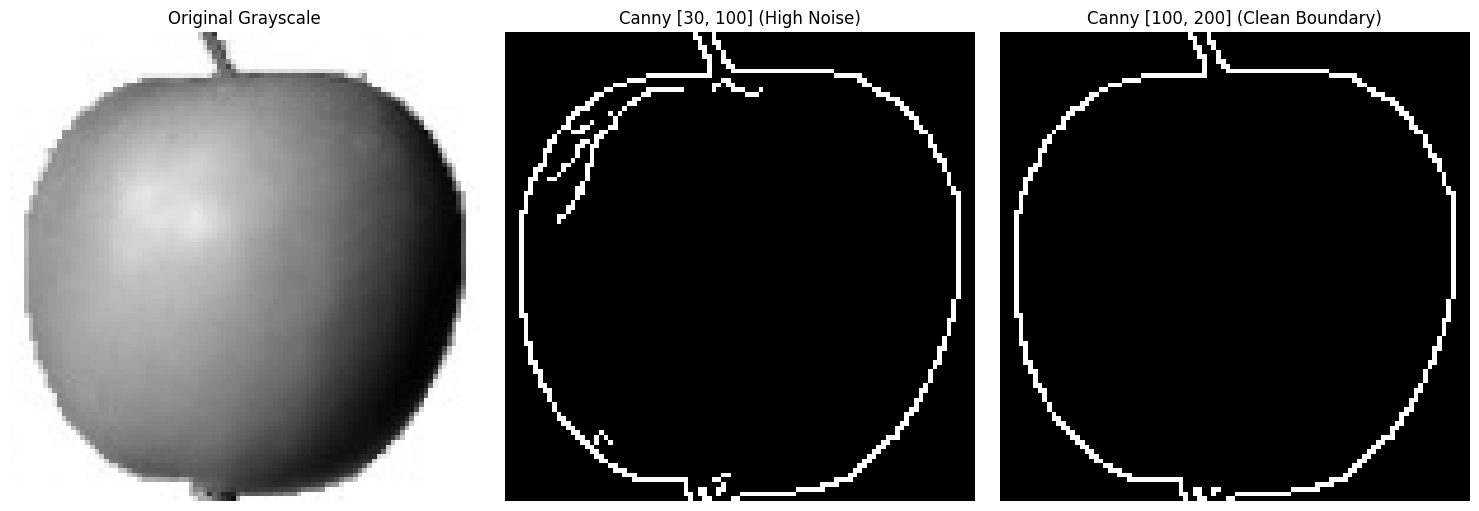

Canny Edge Detection Pipeline Stages:
1. Noise Mitigation: Gaussian smoothing is applied to damp sensor noise.
2. Gradient Field Computation: Sobel filters retrieve spatial derivative arrays (Ix, Iy) to estimate intensity gradients.
3. Non-Maximum Suppression (NMS): Local gradient direction search thins thick edge responses into single-pixel lines.
4. Double Thresholding: High and low limits filter strong edge seeds vs weak candidate pixels.
5. Hysteresis Edge Tracking: Graph-based connectivity traces weak edge strings attached directly to strong edge markers.


In [13]:
# D.1: Hysteresis Canny Tuning
green_bgr = cv2.imread(IMAGE_MAP['green_apple.jpg'])
green_gray = cv2.cvtColor(green_bgr, cv2.COLOR_BGR2GRAY)

edges_30_100 = cv2.Canny(green_gray, 30, 100)
edges_100_200 = cv2.Canny(green_gray, 100, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(green_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(edges_30_100, cmap='gray')
axes[1].set_title('Canny [30, 100] (High Noise)')
axes[1].axis('off')

axes[2].imshow(edges_100_200, cmap='gray')
axes[2].set_title('Canny [100, 200] (Clean Boundary)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("Canny Edge Detection Pipeline Stages:")
print("1. Noise Mitigation: Gaussian smoothing is applied to damp sensor noise.")
print("2. Gradient Field Computation: Sobel filters retrieve spatial derivative arrays (Ix, Iy) to estimate intensity gradients.")
print("3. Non-Maximum Suppression (NMS): Local gradient direction search thins thick edge responses into single-pixel lines.")
print("4. Double Thresholding: High and low limits filter strong edge seeds vs weak candidate pixels.")
print("5. Hysteresis Edge Tracking: Graph-based connectivity traces weak edge strings attached directly to strong edge markers.")


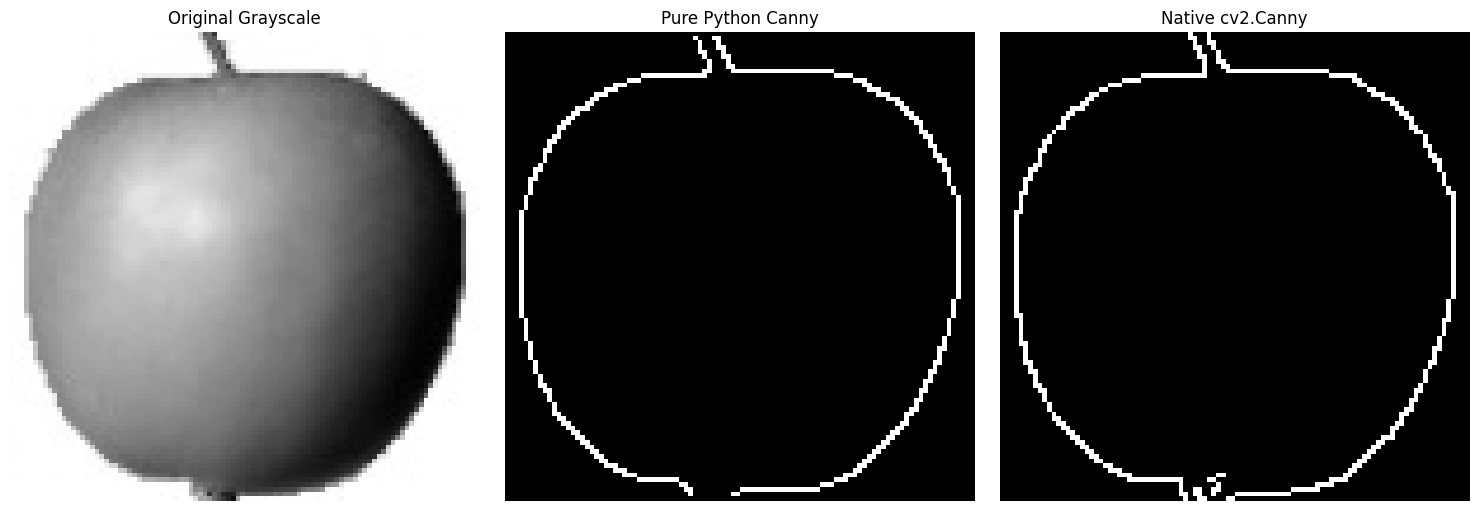

In [14]:
# D.2: Pure Python Canny Pipeline
class CannyEdgeDetector:
    def __init__(self, low_t, high_t):
        self.low_t = low_t
        self.high_t = high_t

    def detect(self, image):
        # Stage 1: Gaussian Blur
        blur = cv2.GaussianBlur(image.astype(np.float32), (5, 5), 1.4)
        
        # Stage 2: Spatial Gradients
        gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(gx**2 + gy**2)
        direction = np.arctan2(gy, gx) * 180.0 / np.pi
        direction[direction < 0] += 180.0
        
        # Stage 3: Non-Maximum Suppression (NMS)
        h, w = image.shape
        nms = np.zeros_like(mag, dtype=np.float32)
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                angle = direction[i, j]
                # Quantize orientation to 4 directions (0, 45, 90, 135 degrees)
                if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                    neighbors = [mag[i, j - 1], mag[i, j + 1]]
                elif (22.5 <= angle < 67.5):
                    neighbors = [mag[i - 1, j - 1], mag[i + 1, j + 1]]
                elif (67.5 <= angle < 112.5):
                    neighbors = [mag[i - 1, j], mag[i + 1, j]]
                else: # 112.5 <= angle < 157.5
                    neighbors = [mag[i - 1, j + 1], mag[i + 1, j - 1]]
                
                if mag[i, j] >= max(neighbors):
                    nms[i, j] = mag[i, j]
        
        # Stage 4: Double Thresholding
        strong = nms >= self.high_t
        weak = (nms >= self.low_t) & (nms < self.high_t)
        
        # Stage 5: Edge Tracking by Hysteresis
        output = np.zeros_like(image, dtype=np.uint8)
        output[strong] = 255
        
        strong_y, strong_x = np.where(strong)
        stack = list(zip(strong_y, strong_x))
        visited = set(stack)
        
        while stack:
            y, x = stack.pop()
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w:
                        if weak[ny, nx] and (ny, nx) not in visited:
                            output[ny, nx] = 255
                            visited.add((ny, nx))
                            stack.append((ny, nx))
                            
        return output

detector = CannyEdgeDetector(low_t=50, high_t=150)
custom_edges = detector.detect(green_gray)
opencv_edges = cv2.Canny(green_gray, 50, 150)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(green_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(custom_edges, cmap='gray')
axes[1].set_title('Pure Python Canny')
axes[1].axis('off')

axes[2].imshow(opencv_edges, cmap='gray')
axes[2].set_title('Native cv2.Canny')
axes[2].axis('off')

plt.tight_layout()
plt.show()


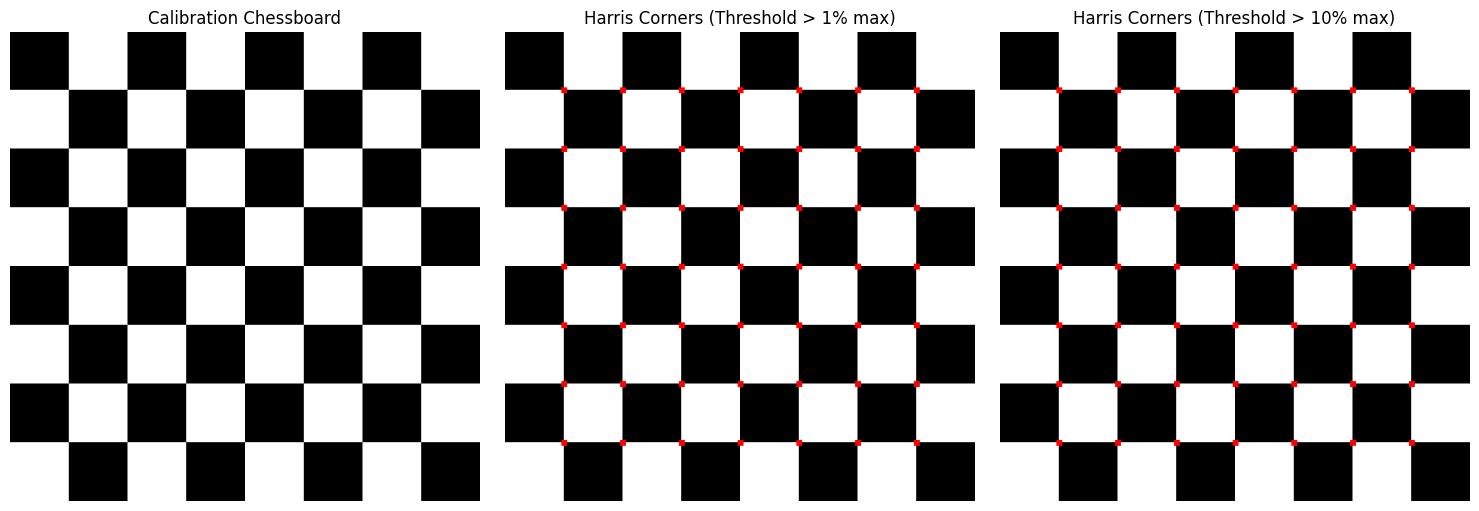

In [15]:
# D.3: Harris Corner Space Calibration
chess_bgr = cv2.imread(IMAGE_MAP['chessboard.png'])
chess_rgb = cv2.cvtColor(chess_bgr, cv2.COLOR_BGR2RGB)
chess_gray = cv2.cvtColor(chess_bgr, cv2.COLOR_BGR2GRAY)

harris_response = cv2.cornerHarris(chess_gray, blockSize=2, ksize=3, k=0.04)

corners_1pct = chess_rgb.copy()
corners_10pct = chess_rgb.copy()

# Isolate response thresholds at 1% and 10% levels
mask_1pct = harris_response > 0.01 * harris_response.max()
mask_10pct = harris_response > 0.10 * harris_response.max()

# Dilate response points to render them as marked dots on plots
dilated_1pct = cv2.dilate(mask_1pct.astype(np.uint8), np.ones((3, 3)))
dilated_10pct = cv2.dilate(mask_10pct.astype(np.uint8), np.ones((3, 3)))

corners_1pct[dilated_1pct > 0] = [255, 0, 0]
corners_10pct[dilated_10pct > 0] = [255, 0, 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(chess_rgb)
axes[0].set_title('Calibration Chessboard')
axes[0].axis('off')

axes[1].imshow(corners_1pct)
axes[1].set_title('Harris Corners (Threshold > 1% max)')
axes[1].axis('off')

axes[2].imshow(corners_10pct)
axes[2].set_title('Harris Corners (Threshold > 10% max)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


Hough Circle Batch Estimation: Identified 84 round fruits.


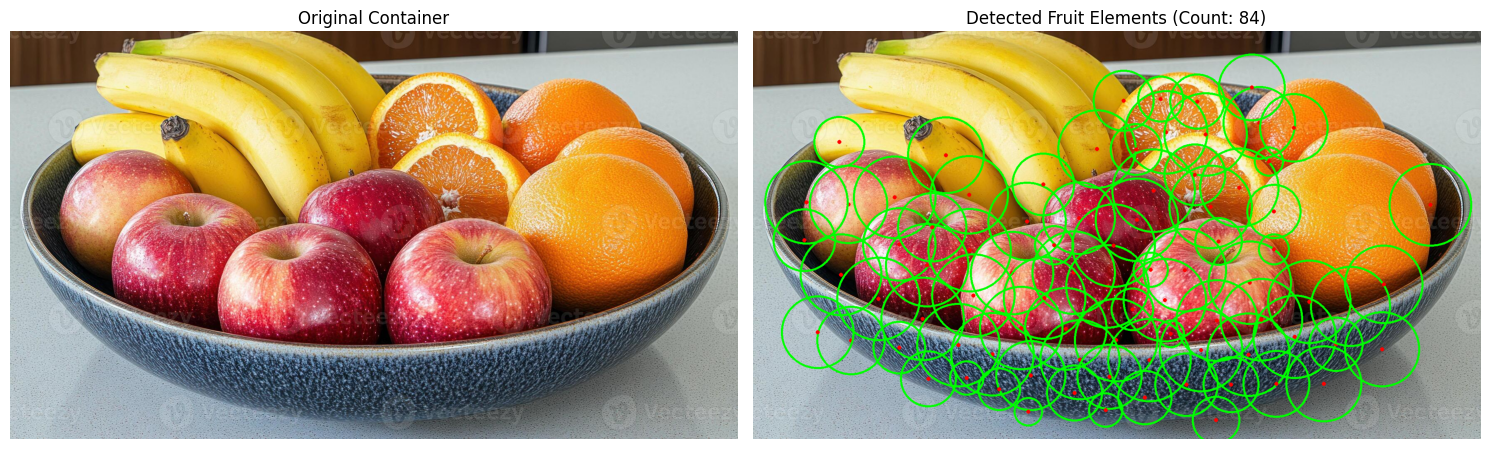

In [16]:
# D.4: Hough Circle Batch Estimation
bowl_bgr = cv2.imread(IMAGE_MAP['mixed_bowl.jpg'])
bowl_rgb = cv2.cvtColor(bowl_bgr, cv2.COLOR_BGR2RGB)
bowl_gray = cv2.cvtColor(bowl_bgr, cv2.COLOR_BGR2GRAY)
bowl_blur = cv2.GaussianBlur(bowl_gray, (9, 9), 2)

# Hough Circle Transform: minDist=80, param1=50, param2=35, minRadius=30, maxRadius=100
circles = cv2.HoughCircles(
    bowl_blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,
    param1=50,
    param2=35,
    minRadius=30,
    maxRadius=100
)

highlighted_bowl = bowl_rgb.copy()
count = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    for c in circles[0, :]:
        # Draw circle boundary in green
        cv2.circle(highlighted_bowl, (c[0], c[1]), c[2], (0, 255, 0), 4)
        # Draw center point in red
        cv2.circle(highlighted_bowl, (c[0], c[1]), 2, (255, 0, 0), 6)
        count += 1

print(f"Hough Circle Batch Estimation: Identified {count} round fruits.")

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].imshow(bowl_rgb)
axes[0].set_title('Original Container')
axes[0].axis('off')

axes[1].imshow(highlighted_bowl)
axes[1].set_title(f'Detected Fruit Elements (Count: {count})')
axes[1].axis('off')

plt.tight_layout()
plt.show()


File successfully saved to: output\isolated_fruit_profile.png


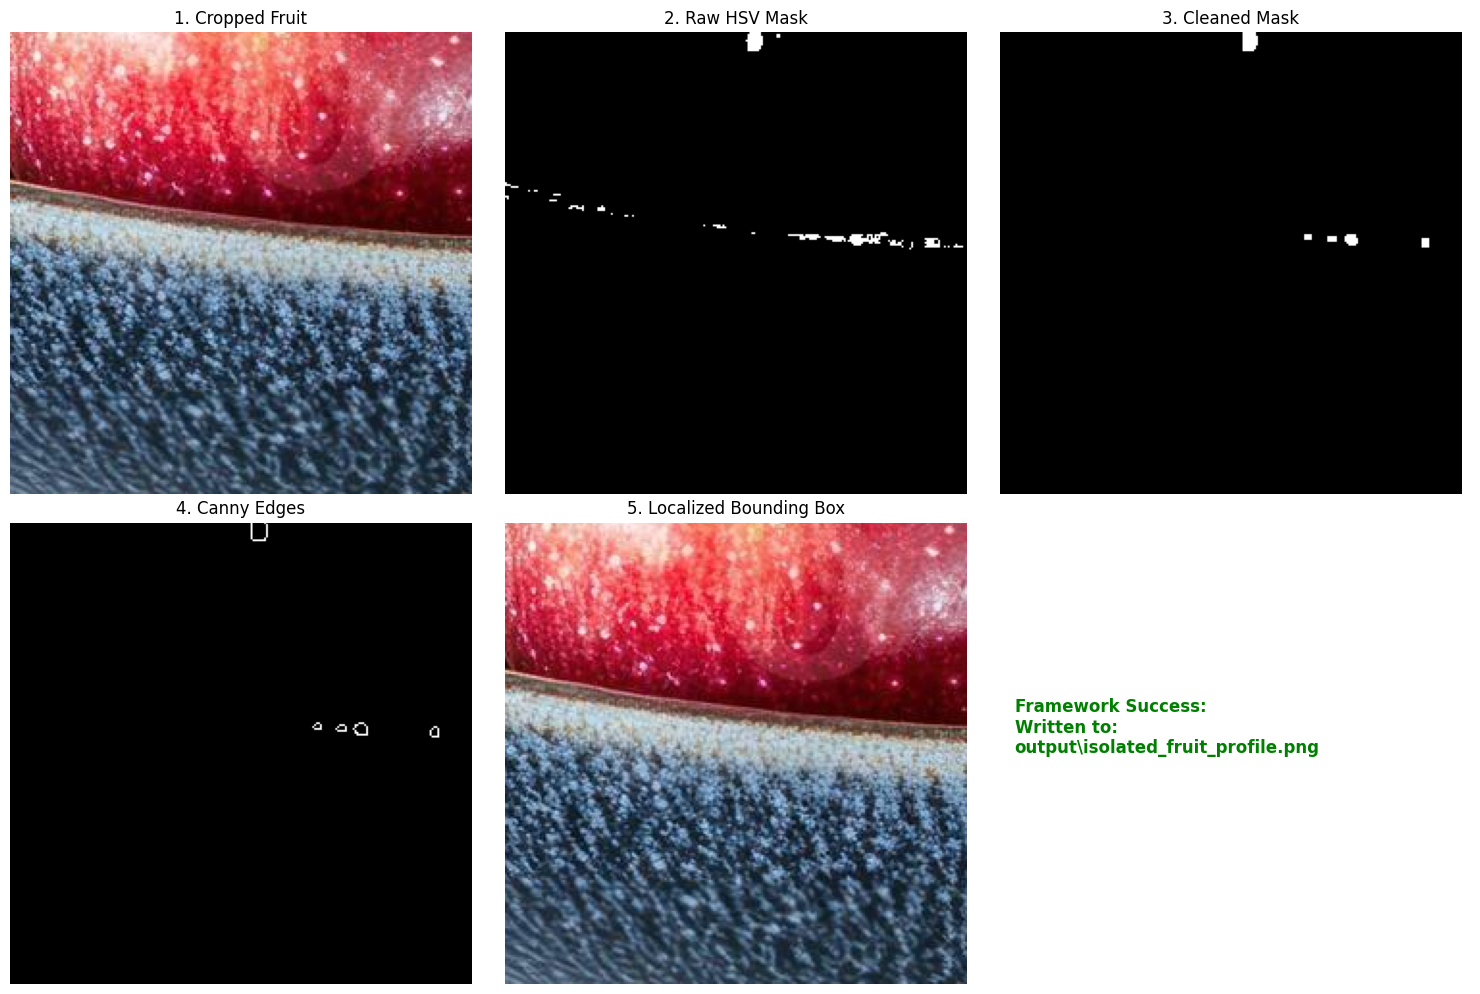

In [17]:
# D.5: Production-Grade Pipeline Integration
def safe_imwrite(path, img):
    directory = os.path.dirname(path)
    if directory and not os.path.exists(directory):
        try:
            os.makedirs(directory, exist_ok=True)
            print(f"Directory created successfully: '{directory}'")
        except Exception as e:
            print(f"Failed to create directory '{directory}': {e}")
            return False
            
    target_dir = directory if directory else '.'
    if os.access(target_dir, os.W_OK):
        success = cv2.imwrite(path, img)
        if success:
            print(f"File successfully saved to: {path}")
            return True
        else:
            print(f"cv2.imwrite failed to save: {path}")
            return False
    else:
        print(f"Permission Error: No write access to directory: '{target_dir}'")
        return False

# Select and segment one fruit from the bowl (simulate crop or slice of mixed_bowl)
bowl_bgr = cv2.imread(IMAGE_MAP['mixed_bowl.jpg'])

# Crop a fruit sector (x: 509 to 749, y: 646 to 886)
crop_bgr = bowl_bgr[646:886, 509:749]
crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
crop_hsv = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2HSV)

# Isolate target orange-like peach/apple
lower_orange = np.array([10, 80, 80])
upper_orange = np.array([25, 255, 255])
orange_mask = cv2.inRange(crop_hsv, lower_orange, upper_orange)

# Morphological cleaning
kernel_3x3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
cleaned_orange = cv2.morphologyEx(orange_mask, cv2.MORPH_OPEN, kernel_3x3)
cleaned_orange = cv2.morphologyEx(cleaned_orange, cv2.MORPH_CLOSE, kernel_3x3)

# Canny Edge detection
orange_edges = cv2.Canny(cleaned_orange, 50, 150)

# Bounding Box localization
contours, _ = cv2.findContours(cleaned_orange, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
highlighted_orange = crop_rgb.copy()
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w > 20 and h > 20:
        cv2.rectangle(highlighted_orange, (x, y), (x + w, y + h), (0, 255, 0), 2)
        print(f"Fruit localized bounding box coordinates: x={x}, y={y}, w={w}, h={h}")

# Safe disk output
output_dir = 'output'
output_file = os.path.join(output_dir, 'isolated_fruit_profile.png')
safe_imwrite(output_file, cv2.cvtColor(highlighted_orange, cv2.COLOR_RGB2BGR))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(crop_rgb)
axes[0, 0].set_title('1. Cropped Fruit')
axes[0, 0].axis('off')

axes[0, 1].imshow(orange_mask, cmap='gray')
axes[0, 1].set_title('2. Raw HSV Mask')
axes[0, 1].axis('off')

axes[0, 2].imshow(cleaned_orange, cmap='gray')
axes[0, 2].set_title('3. Cleaned Mask')
axes[0, 2].axis('off')

axes[1, 0].imshow(orange_edges, cmap='gray')
axes[1, 0].set_title('4. Canny Edges')
axes[1, 0].axis('off')

axes[1, 1].imshow(highlighted_orange)
axes[1, 1].set_title('5. Localized Bounding Box')
axes[1, 1].axis('off')

axes[1, 2].axis('off')
axes[1, 2].text(0.05, 0.5, f"Framework Success:\nWritten to:\n{output_file}", fontsize=12, color='green', weight='bold')

plt.tight_layout()
plt.show()
